# Membership Inference Attack: Phase 1

In [1]:
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "requirements.txt").is_file():
    raise RuntimeError("Open this notebook from the repository root. See README.md for setup.")

print(f"Project root: {project_root}")


Project root: /Users/andyli233/CMU/18-734/18734-project-phase-1


In [2]:
import subprocess
import sys

subprocess.run([sys.executable, "scripts/verify_model.py"], check=True)


Checkpoint: models/gpt2_phase1/model.safetensors
Size:       497,774,208 bytes
SHA-256:    1a205d3e68c7997ace3cc2641c746f93cb14d6b1c2631b24c544430bd30bc83d
Model checkpoint verification: PASS


CompletedProcess(args=['/Users/andyli233/CMU/18-734/18734-project-phase-1/.phase1/bin/python', 'scripts/verify_model.py'], returncode=0)

### Variables and libraries

In [3]:
# Install dependencies before starting the notebook; see README.md.
# To install into the active kernel, uncomment the next line and restart the kernel.
# %pip install -r requirements.txt


In [4]:
import json
import os
import random
os.environ.setdefault("TRANSFORMERS_NO_TORCHVISION", "1")

import torch
import numpy as np
from datasets import Dataset
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import roc_auc_score, roc_curve, auc as _auc
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


/Users/andyli233/CMU/18-734/18734-project-phase-1/.phase1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
target_model_dir = project_root / "models" / "gpt2_phase1"
data_dir = project_root / "data" / "wiki_json"
batch_size = 25

# you may change block size if you like (max length for the tokenizer below)
block_size = 256

### Data pre-processing

In [6]:
def tokenize_dataset(ds, tok, max_len):
    ds = ds.filter(lambda ex: ex.get("text", None) and len(ex["text"].strip()) > 0)

    def _map(ex):
        out = tok(ex["text"], truncation=True, padding=True, max_length=max_len, return_attention_mask=True)
        out["labels"] = out["input_ids"].copy()
        return out

    ds = ds.map(_map, batched=True, remove_columns=ds.column_names)
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    return ds

def _read_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

In [24]:
# for tests, you may only load a part of the data to save time while implementing,
# as running all 2000 samples on CPU may be slow, but not a problem here for GPU

# load test data
N = 25

data_dir = Path(data_dir)
test_path = data_dir / "test.json"
test_items = _read_json(test_path)
if N is not None:
    test_items = test_items[:N]
ds_test = Dataset.from_dict({"text": test_items})

# tokenizer the test data
tokenizer = AutoTokenizer.from_pretrained(target_model_dir, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side="right"

ds_test = tokenize_dataset(ds_test, tokenizer, block_size)
dl_test = DataLoader(ds_test, batch_size=batch_size)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# you may load the model using the code:
# model = AutoModelForCausalLM.from_pretrained(target_model_dir, dtype="auto").to(device)

Map: 100%|██████████| 25/25 [00:00<00:00, 4397.47 examples/s]

Using device: mps


In [8]:
model = AutoModelForCausalLM.from_pretrained(target_model_dir, dtype="auto").to(device)

In [11]:
for batch in dl_test:
    print(batch["input_ids"].shape)
    break

torch.Size([25, 256])


### MIA

Implement your attack here!

In [ ]:
# implement your attack here
k = 0.1 
threshold = 0.5

@torch.no_grad()
def your_attack(
    model,
    dl_test,
    device
):
    scores_test = []
    for batch in dl_test:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        print(logits.shape)

        log_probs = torch.log_softmax(logits, dim=-1)
        print(log_probs.shape)

        log_probs_out = torch.gather(log_probs, dim=2, index=input_ids.unsqueeze(-1)).squeeze(-1)
        print(log_probs_out.shape)

        k_length = int(k * log_probs.shape[1])
        topks = torch.sort(log_probs_out, axis=1).values[:, :k_length]
        scores = topks.mean(axis=1) / k_length
        scores_test.extend(scores.tolist())
        print(scores)
    return scores_test

scores_test = your_attack(model, dl_test, device)

torch.Size([25, 256, 50257])
torch.Size([25, 256, 50257])
torch.Size([25, 256])
tensor([0.5194, 0.5959, 0.4563, 0.5272, 0.5985, 0.5374, 0.5173, 0.5020, 0.6696,
        0.5744, 0.6108, 0.5384, 0.7679, 0.6674, 0.6068, 0.5786, 0.6739, 0.4894,
        0.5530, 0.6911, 0.4624, 0.7372, 0.6424, 0.7094, 0.4707],
       device='mps:0')


### Visualization

In [25]:
# load the label here to compute the performance, you will only have full access to the label in phase 1 as a warm-up
label_path = data_dir / "test_label.json"
label_items = _read_json(label_path)
if N is not None:
    label_items = label_items[:N]

y_true = np.array(label_items)
scores = np.array(scores_test)
fpr, tpr, thr = roc_curve(y_true, scores)
auc_val = roc_auc_score(y_true, scores)
print(auc_val) # area under curve

# some tpr fpr
print(max(tpr[fpr < 0.01])) # TPR @ 0.01FPR
print(max(tpr[fpr < 0.05])) # TPR @ 0.05FPR
# report this three metrics in your report!!

0.3846153846153846
0.0
0.0


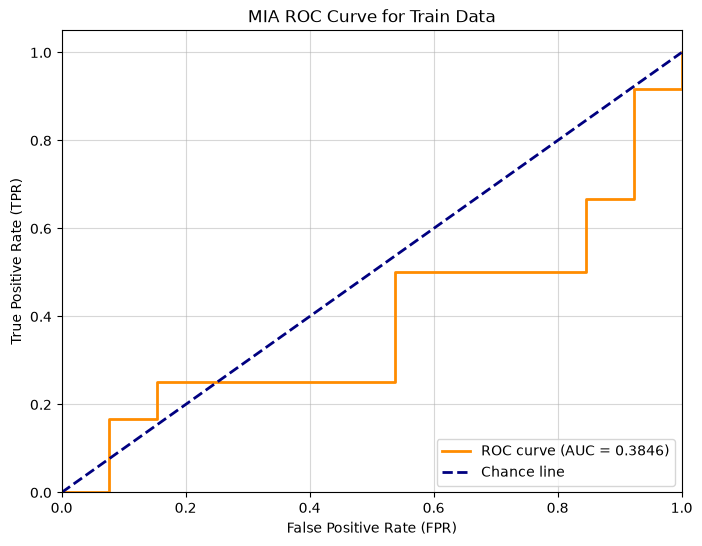

In [26]:
# draw ROC curve and attach the figure in the report
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance line')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title(f'MIA ROC Curve for Train Data')
plt.legend(loc="lower right")
plt.grid(alpha=0.5)
plt.show()